#### HuggingFace transformers inference

In [1]:
import torch.cuda
from transformers import AutoModelForCausalLM, AutoTokenizer

model_name = "Qwen/Qwen3-1.7B"

# use half-precision inference and GPU if available
dtype = torch.bfloat16 if torch.cuda.is_available() else torch.float16
device = "cuda" if torch.cuda.is_available() else "cpu"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(model_name, dtype=dtype, device_map=device)

# prepare the model input
prompt = "How important is LLMOps on scale 0-10?"
messages = [{"role": "user", "content": prompt}]
text = tokenizer.apply_chat_template(
    messages,
    tokenize=False,
    add_generation_prompt=True,
    enable_thinking=True,  # use thinking / reasoning?
)
model_inputs = tokenizer([text], return_tensors="pt").to(model.device)

# conduct text completion
generated_ids = model.generate(
    **model_inputs,
    max_new_tokens=32768,  # if not provided, use max context 32k
)
output_ids = generated_ids[0][len(model_inputs.input_ids[0]):].tolist()

# parse only output, not thinking content
try:
    # find token 151668 "</think>"
    index = len(output_ids) - output_ids[::-1].index(151668)
except ValueError:
    index = 0

content = tokenizer.decode(output_ids[index:], skip_special_tokens=True).strip("\n")
print("Answer:\n", content)


/home/annacz/PyCharmMiscProject/ipum-lab13/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading checkpoint shards: 100%|██████████| 2/2 [00:01<00:00,  1.48it/s]


Answer:
 The importance of LLMOps (Large Language Model Operations) can be evaluated on a scale of **0 to 10**, depending on the context, industry, and specific use cases. Here's a structured analysis:

---

### **Key Factors Influencing LLMOps Importance (0–10):**
1. **Scale of the Organization**  
   - **High (9–10)**: Large enterprises with complex, mission-critical models (e.g., healthcare, finance, customer service) require robust LLMOps for reliability, compliance, and scalability.  
   - **Low (1–2)**: Small startups or niche use cases may prioritize LLMOps only if the models are critical to their operations.

2. **Use Case Criticality**  
   - **High (9–10)**: Models in high-stakes environments (e.g., autonomous systems, legal/financial AI) demand rigorous monitoring, security, and compliance.  
   - **Low (1–2)**: Simple, non-critical models (e.g., chatbots for internal use) may not require LLMOps unless there are specific risks.

3. **Regulatory and Compliance Requirements** 

In [2]:
import torch.cuda
from transformers import pipeline

model = pipeline(
    task="text-generation",
    model="Qwen/Qwen3-1.7B",
    dtype=torch.bfloat16 if torch.cuda.is_available() else torch.float16,
    device="cuda" if torch.cuda.is_available() else "cpu",
)

prompt = "How important is LLMOps on scale 0-10?"
messages = [{"role": "user", "content": prompt}]

messages = model(messages, max_new_tokens=32768)[0]["generated_text"]
content = messages[-1]["content"].strip()
print("Answer:\n", content)


Loading checkpoint shards: 100%|██████████| 2/2 [00:00<00:00, 123.78it/s]
Device set to use cuda


Answer:
 <think>
Okay, the user is asking how important LLMOps is on a scale from 0 to 10. Let me start by understanding what LLMOps means. It's the practice of managing and maintaining large language models, right? So, the user wants to know how crucial this is in terms of importance.

First, I should consider the different aspects of LLMOps. There's the technical side, like infrastructure, deployment, monitoring, and scaling. Then there's the business side, such as cost efficiency, performance, and user experience. Also, the challenges involved, like model training, data management, and integration with existing systems.

I need to break down the key factors that contribute to the importance of LLMOps. For example, if a company uses a large model, they need to ensure it's scalable and reliable. Without proper LLMOps, they might face issues like slow deployment, poor performance, or even model degradation over time. On the other hand, good LLMOps can lead to faster deployment, better 

#### vLLM inference

**Exercise 1:**

**Original (base) model:**

ran in terminal:
```
vllm serve Qwen/Qwen3-1.7B --port 8000 --max-model-len 8192
```
**results:**

(EngineCore pid=10631) INFO 06-27 10:34:15 [gpu_worker.py:456] Available KV cache memory: 2.86 GiB

(EngineCore pid=10631) INFO 06-27 10:34:15 [kv_cache_utils.py:1316] GPU KV cache size: 26,736 tokens

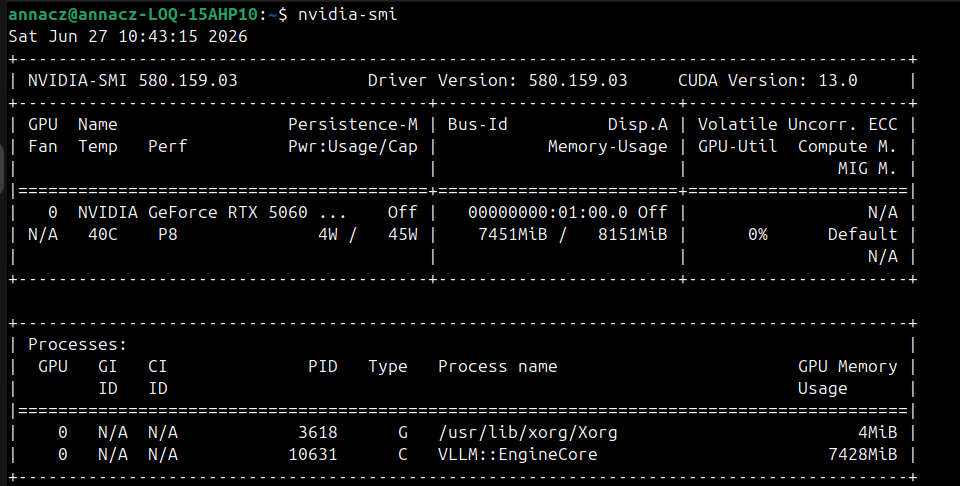

In [7]:
import time
from openai import OpenAI

# those settings use vLLM server
client = OpenAI(api_key="EMPTY", base_url="http://localhost:8000/v1")

prompts = [
    "How important is LLMOps on scale 0-10?",
    "What is LLMOps?",
    "Explain the key components of an LLM serving infrastructure in production.",
    "What are the main challenges of deploying large language models at scale?",
    "Describe common strategies for reducing LLM inference latency in production systems.",
    "What is KV cache and why is it important for efficient LLM inference?",
    "Compare different model quantization techniques.",
    "What metrics should be monitored when running an LLM inference server in production?",
    "Explain the concept of continuous batching in LLM serving frameworks like vLLM.",
    "How does dynamic quantization with bitsandbytes affect model accuracy versus memory savings?",
]

start_time = time.time()

for i, prompt in enumerate(prompts):
    chat_response = client.chat.completions.create(
        model="",  # use the default server model
        messages=[{"role": "developer", "content": "You are a helpful assistant."},
                  {"role": "user", "content": prompt}
                  ],
        max_completion_tokens=100,
        # turn off thinking for Qwen with /no_think
        extra_body={"chat_template_kwargs": {"enable_thinking": False}}
    )
    content = chat_response.choices[0].message.content.strip()
    print(f"Prompt [{i+1}/10]:, {prompt}\n")
    print(f"Response: {content}\n\n")

end_time = time.time()
total_time = end_time - start_time

print(f"Total serving time: {total_time:.2f} seconds.")


Prompt [1/10]:, How important is LLMOps on scale 0-10?

Response: The importance of **LLMOps (Large Language Model Operations)** on a scale of 0 to 10 is **highly significant**, and it's typically **9 or 10**. Here's a breakdown of why it's so important:

---

### **Why LLMOps is Critical (Scale 9-10):**

#### 1. **Operational Efficiency**
LLMOps ensures that large language models (LLMs) are deployed, maintained, and scaled efficiently.


Prompt [2/10]:, What is LLMOps?

Response: LLMOps (Large Language Model Operations) is a field that focuses on the **continuous operation, management, and optimization of large language models (LLMs)**. It encompasses the processes and practices used to ensure that these models are reliable, performant, and maintainable in real-world environments.

### Key Components of LLMOps:

1. **Model Training and Tuning**:
   - Continuously refining and fine-tuning models to improve performance on specific tasks.
   - Managing hyperparameters,


Prompt [3/10]:, 

**Quantized model:**

run in terminal:
```
vllm serve Qwen/Qwen3-1.7B --port 8000 --max-model-len 8192 --quantization bitsandbytes --load-format bitsandbytes
```
**results:**

(EngineCore pid=16811) INFO 06-27 11:23:38 [gpu_worker.py:456] Available KV cache memory: 4.74 GiB

(EngineCore pid=16811) INFO 06-27 11:23:38 [kv_cache_utils.py:1316] GPU KV cache size: 44,368 tokens

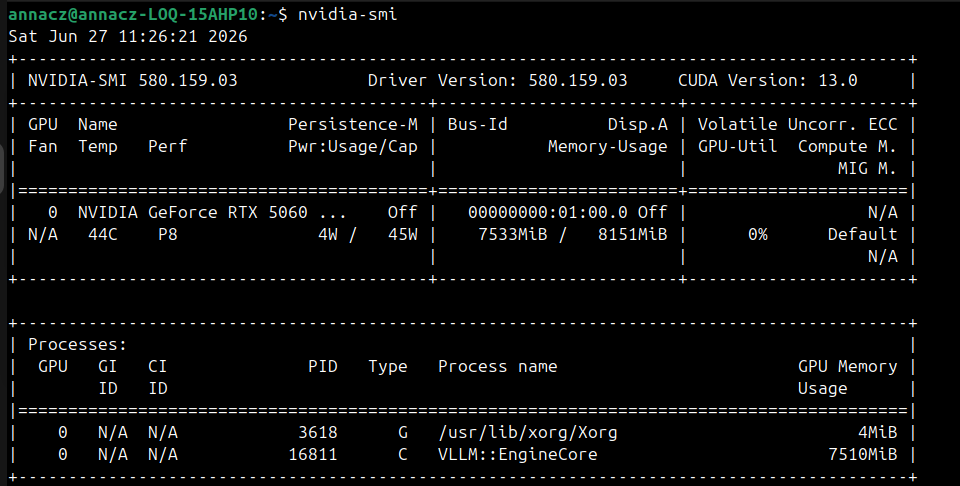

In [8]:
import time
from openai import OpenAI

# those settings use vLLM server
client = OpenAI(api_key="EMPTY", base_url="http://localhost:8000/v1")

prompts = [
    "How important is LLMOps on scale 0-10?",
    "What is LLMOps?",
    "Explain the key components of an LLM serving infrastructure in production.",
    "What are the main challenges of deploying large language models at scale?",
    "Describe common strategies for reducing LLM inference latency in production systems.",
    "What is KV cache and why is it important for efficient LLM inference?",
    "Compare different model quantization techniques.",
    "What metrics should be monitored when running an LLM inference server in production?",
    "Explain the concept of continuous batching in LLM serving frameworks like vLLM.",
    "How does dynamic quantization with bitsandbytes affect model accuracy versus memory savings?",
]

start_time = time.time()

for i, prompt in enumerate(prompts):
    chat_response = client.chat.completions.create(
        model="",  # use the default server model
        messages=[{"role": "developer", "content": "You are a helpful assistant."},
                  {"role": "user", "content": prompt}
                  ],
        max_completion_tokens=100,
        # turn off thinking for Qwen with /no_think
        extra_body={"chat_template_kwargs": {"enable_thinking": False}}
    )
    content = chat_response.choices[0].message.content.strip()
    print(f"Prompt [{i+1}/10]:, {prompt}\n")
    print(f"Response: {content}\n\n")

end_time = time.time()
total_time = end_time - start_time

print(f"Total serving time: {total_time:.2f} seconds.")


Prompt [1/10]:, How important is LLMOps on scale 0-10?

Response: The importance of **LLMOps** (Large Language Model Operations) on a **scale 0-10** (where 10 is the highest, indicating the most critical and complex level of importance) depends on the specific context, industry, and goals of the organization. Here's a breakdown of how LLMOps is typically evaluated on this scale:

---

### **Scale 0-10: Importance of LLMOps**

| **Scale** | **Description** | **Explanation


Prompt [2/10]:, What is LLMOps?

Response: LLMOps is an **operationalization** of **Large Language Models (LLMs)**, combining **machine learning** with **operations** to manage and maintain large language models in production environments.

### Key Concepts of LLMOps:

1. **Operationalization of AI Models**:
   - LLMOps is not just about building models; it's about **operating** them effectively.
   - It involves the **continuous monitoring**, **scaling**, and **maintenance** of models in


Prompt [3/10]:, Explain th

**Comments:**

Applying dynamic quantization (bitsandbytes) to the Qwen3-1.7B model significantly optimized vLLM serving infrastructure. It reduced inference latency by nearly 40% (from 14.76s to 9.06s) and expanded the available KV cache capacity by 65% (from 26k to 44k tokens), enabling much higher throughput on the same GPU hardware."

#### Tool usage

```
vllm serve Qwen/Qwen3-1.7B \
  --port 8000 \
  --max-model-len 8192 \
  --enable-auto-tool-choice \
  --tool-call-parser hermes
```

In [9]:
import datetime
import json
from typing import Callable

from openai import OpenAI


def make_llm_request(prompt: str) -> str:
    client = OpenAI(api_key="EMPTY", base_url="http://localhost:8000/v1")

    messages = [
        {"role": "developer", "content": "You are a weather assistant."},
        {"role": "user", "content": prompt},
    ]

    tool_definitions, tool_name_to_func = get_tool_definitions()

    # guard: loop limit, we break as soon as we get an answer
    for _ in range(10):
        response = client.chat.completions.create(
            model="",
            messages=messages,
            tools=tool_definitions,  # always pass all tools in this example
            tool_choice="auto",
            max_completion_tokens=1000,
            extra_body={"chat_template_kwargs": {"enable_thinking": False}},
        )
        resp_message = response.choices[0].message
        messages.append(resp_message.model_dump())

        print(f"Generated message: {resp_message.model_dump()}")
        print()

        # parse possible tool calls (assume only "function" tools)
        if resp_message.tool_calls:
            for tool_call in resp_message.tool_calls:
                func_name = tool_call.function.name
                func_args = json.loads(tool_call.function.arguments)

                # call tool, serialize result, append to messages
                func = tool_name_to_func[func_name]
                func_result = func(**func_args)

                messages.append(
                    {
                        "role": "tool",
                        "content": json.dumps(func_result),
                        "tool_call_id": tool_call.id,
                    }
                )
        else:
            # no tool calls, we're done
            return resp_message.content

    # we should not get here
    last_response = resp_message.content
    return f"Could not resolve request, last response: {last_response}"


def get_tool_definitions() -> tuple[list[dict], dict[str, Callable]]:
    tool_definitions = [
        {
            "type": "function",
            "function": {
                "name": "get_current_date",
                "description": 'Get current date in the format "Year-Month-Day" (YYYY-MM-DD).',
                "parameters": {},
            },
        },
        {
            "type": "function",
            "function": {
                "name": "get_weather_forecast",
                "description": "Get weather forecast at given country, city, and date.",
                "parameters": {
                    "type": "object",
                    "properties": {
                        "country": {
                            "type": "string",
                            "description": "The country the city is in.",
                        },
                        "city": {
                            "type": "string",
                            "description": "The city to get the weather for.",
                        },
                        "date": {
                            "type": "string",
                            "description": (
                                "The date to get the weather for, "
                                'in the format "Year-Month-Day" (YYYY-MM-DD). '
                                "At most 4 weeks into the future."
                            ),
                        },
                    },
                    "required": ["country", "city", "date"],
                },
            },
        },
    ]

    tool_name_to_callable = {
        "get_current_date": current_date_tool,
        "get_weather_forecast": weather_forecast_tool,
    }

    return tool_definitions, tool_name_to_callable


def current_date_tool() -> str:
    return datetime.date.today().isoformat()


def weather_forecast_tool(country: str, city: str, date: str) -> str:
    if country.lower() in {"united kingdom", "uk", "england"}:
        return "Fog and rain"
    else:
        return "Sunshine"


if __name__ == "__main__":
    prompt = "What will be weather in Birmingham in two weeks?"
    response = make_llm_request(prompt)
    print("Response:\n", response)

    print()

    prompt = "What will be weather in Warsaw the day after tomorrow?"
    response = make_llm_request(prompt)
    print("Response:\n", response)

    print()

    prompt = "What will be weather in New York in two months?"
    response = make_llm_request(prompt)
    print("Response:\n", response)


Generated message: {'content': None, 'refusal': None, 'role': 'assistant', 'annotations': None, 'audio': None, 'function_call': None, 'tool_calls': [{'id': 'chatcmpl-tool-a1fa525d5aa36728', 'function': {'arguments': '{}', 'name': 'get_current_date'}, 'type': 'function'}], 'reasoning': None}

Generated message: {'content': None, 'refusal': None, 'role': 'assistant', 'annotations': None, 'audio': None, 'function_call': None, 'tool_calls': [{'id': 'chatcmpl-tool-a127a7c70de001a1', 'function': {'arguments': '{"country": "United Kingdom", "city": "Birmingham", "date": "2026-06-27"}', 'name': 'get_weather_forecast'}, 'type': 'function'}], 'reasoning': None}

Generated message: {'content': 'The weather in Birmingham, United Kingdom, on June 27, 2026, is expected to be fog and rain.', 'refusal': None, 'role': 'assistant', 'annotations': None, 'audio': None, 'function_call': None, 'tool_calls': [], 'reasoning': None}

Response:
 The weather in Birmingham, United Kingdom, on June 27, 2026, is ex

**Exercise 2:**

In [21]:
import json
import polars as pl
from typing import Callable
from openai import OpenAI


def make_llm_request2(prompt: str) -> str:
    client = OpenAI(api_key="EMPTY", base_url="http://localhost:8000/v1")

    messages = [
        {"role": "developer", "content": "You are a helpful data analyst assistant."},
        {"role": "user", "content": prompt},
    ]

    tool_definitions, tool_name_to_func = get_tool_definitions2()

    for _ in range(10):
        response = client.chat.completions.create(
            model="",
            messages=messages,
            tools=tool_definitions,
            tool_choice="auto",
            max_completion_tokens=1000,
            extra_body={"chat_template_kwargs": {"enable_thinking": False}},
        )
        resp_message = response.choices[0].message
        messages.append(resp_message.model_dump())

        print(f"Generated message: {resp_message.model_dump()}")
        print()

        if resp_message.tool_calls:
            for tool_call in resp_message.tool_calls:
                func_name = tool_call.function.name
                func_args = json.loads(tool_call.function.arguments)

                func = tool_name_to_func[func_name]
                func_result = func(**func_args)

                messages.append(
                    {
                        "role": "tool",
                        "content": json.dumps(func_result),
                        "tool_call_id": tool_call.id,
                    }
                )
        else:
            return resp_message.content

    last_response = resp_message.content
    return f"Could not resolve request, last response: {last_response}"


def read_remote_csv(url: str) -> str:
    try:
        df = pl.read_csv(url)
        return describe_dataframe(df)
    except Exception as e:
        return f"Error reading CSV: {e}"


def read_remote_parquet(url: str) -> str:
    try:
        df = pl.read_parquet(url)
        return describe_dataframe(df)
    except Exception as e:
        return f"Error reading Parquet: {e}"


def describe_dataframe(df: pl.DataFrame) -> str:
    info = {
        "shape": {"rows": df.shape[0], "columns": df.shape[1]},
        "columns": df.columns,
        "dtypes": {col: str(dtype) for col, dtype in zip(df.columns, df.dtypes)},
        "sample_rows": json.loads(df.head(5).write_json()),
        "statistics": json.loads(df.describe().write_json()),
        "null_counts": df.null_count().row(0, named=True),
    }
    return json.dumps(info)


def get_tool_definitions2() -> tuple[list[dict], dict[str, Callable]]:
    tool_definitions = [
        {
            "type": "function",
            "function": {
                "name": "read_remote_csv",
                "description": "Reads a remote CSV file from a URL and returns its first 20 rows as text.",
                "parameters": {
                    "type": "object",
                    "properties": {
                        "url": {
                            "type": "string",
                            "description": "The direct URL to the CSV file."
                        }
                    },
                    "required": ["url"],
                },
            },
        },
        {
            "type": "function",
            "function": {
                "name": "read_remote_parquet",
                "description": "Reads a remote Parquet file from a URL and returns its first 20 rows as text.",
                "parameters": {
                    "type": "object",
                    "properties": {
                        "url": {
                            "type": "string",
                            "description": "The direct URL to the Parquet file."
                        }
                    },
                    "required": ["url"],
                },
            },
        },
    ]

    tool_name_to_callable = {
        "read_remote_csv": read_remote_csv,
        "read_remote_parquet": read_remote_parquet,
    }

    return tool_definitions, tool_name_to_callable

if __name__ == "__main__":

    print("TEST 1: CSV\n")
    csv_url = "https://d37ci6vzurychx.cloudfront.net/misc/taxi_zone_lookup.csv"
    prompts_csv = [
        f"How many rows and columns does this dataset have? URL: {csv_url}",
        f"What columns are available in this dataset? URL: {csv_url}",
        f"Are there any missing or unknown values in the dataset? URL: {csv_url}",
        f"How many unique boroughs are there and what are they? URL: {csv_url}",
        f"List all zones located at airports? URL: {csv_url}",
        f"How many service zones are listed as N/A or Unknown? List them if exist. URL: {csv_url}",
    ]
    for i, prompt in enumerate(prompts_csv):
        response_csv = make_llm_request2(prompt)
        print(f"Prompt [{i+1}/6]: {prompt}\n")
        print(f"LLM response: {response_csv}\n")
        print("---")

    print("TEST 2: Parquet\n")
    parquet_url = "https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2026-01.parquet"
    prompts_parquet = [
        f"What is the average trip duration? URL: {parquet_url}",
        f"What is the maximum and minimum trip cost? URL: {parquet_url}",
        f"Which pickup zones (PULocationID) are the most popular? URL: {parquet_url}",
        f"What is the data type of each column? URL: {parquet_url}",
        f"Summarize the descriptive statistics (min, max, mean, std). URL: {parquet_url}",
        f"Are there any missing values (null/NaN)? In which columns? URL: {parquet_url}",
    ]
    for i, prompt in enumerate(prompts_parquet):
        response_parquet = make_llm_request2(prompt)
        print(f"Prompt [{i+1}/6]: {prompt}\n")
        print(f"LLM response: {response_parquet}\n")
        print("---")

TEST 1: CSV

Generated message: {'content': None, 'refusal': None, 'role': 'assistant', 'annotations': None, 'audio': None, 'function_call': None, 'tool_calls': [{'id': 'chatcmpl-tool-a0ee2c1eac06e756', 'function': {'arguments': '{"url": "https://d37ci6vzurychx.cloudfront.net/misc/taxi_zone_lookup.csv"}', 'name': 'read_remote_csv'}, 'type': 'function'}], 'reasoning': None}

Generated message: {'content': 'The dataset has 265 rows and 4 columns. The columns are "LocationID", "Borough", "Zone", and "service_zone". The data types are as follows: "LocationID" is an integer, "Borough", "Zone", and "service_zone" are strings. The dataset contains 265 rows and 4 columns.', 'refusal': None, 'role': 'assistant', 'annotations': None, 'audio': None, 'function_call': None, 'tool_calls': [], 'reasoning': None}

Prompt [1/6]: How many rows and columns does this dataset have? URL: https://d37ci6vzurychx.cloudfront.net/misc/taxi_zone_lookup.csv

LLM response: The dataset has 265 rows and 4 columns. Th

#### Model Context Protocol (MCP)

**Exercise 3:**

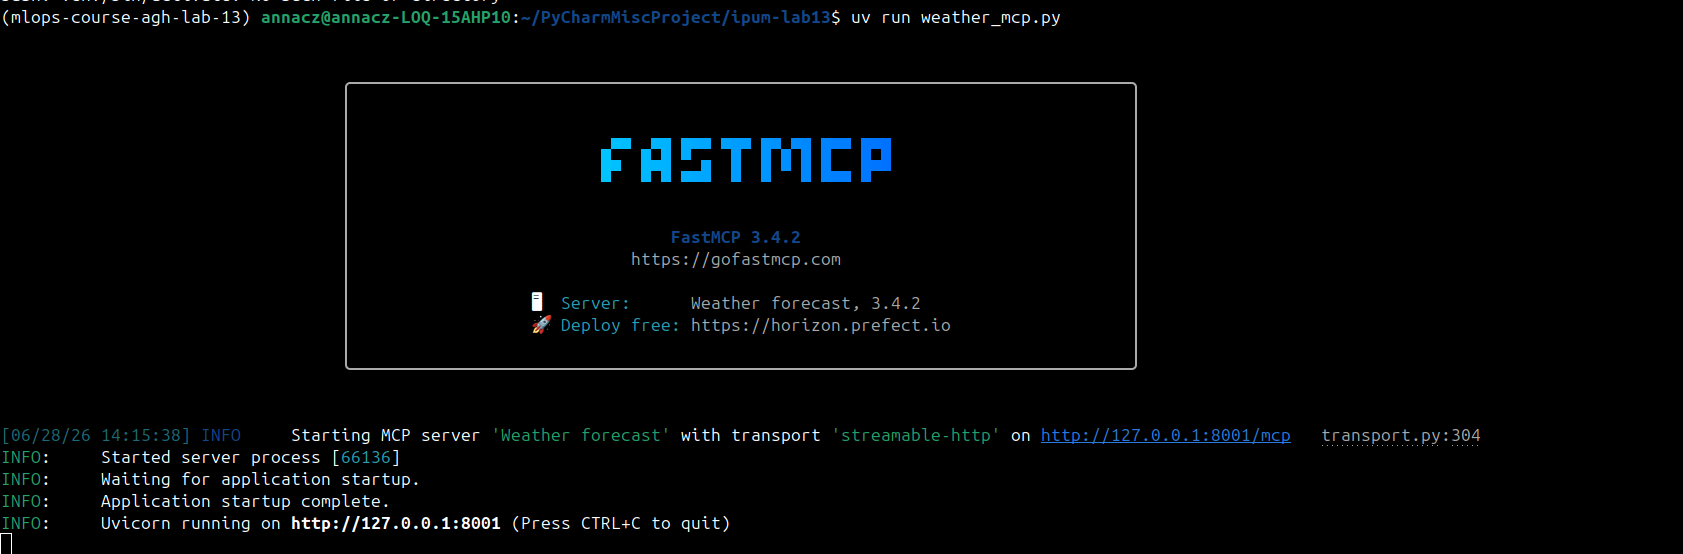

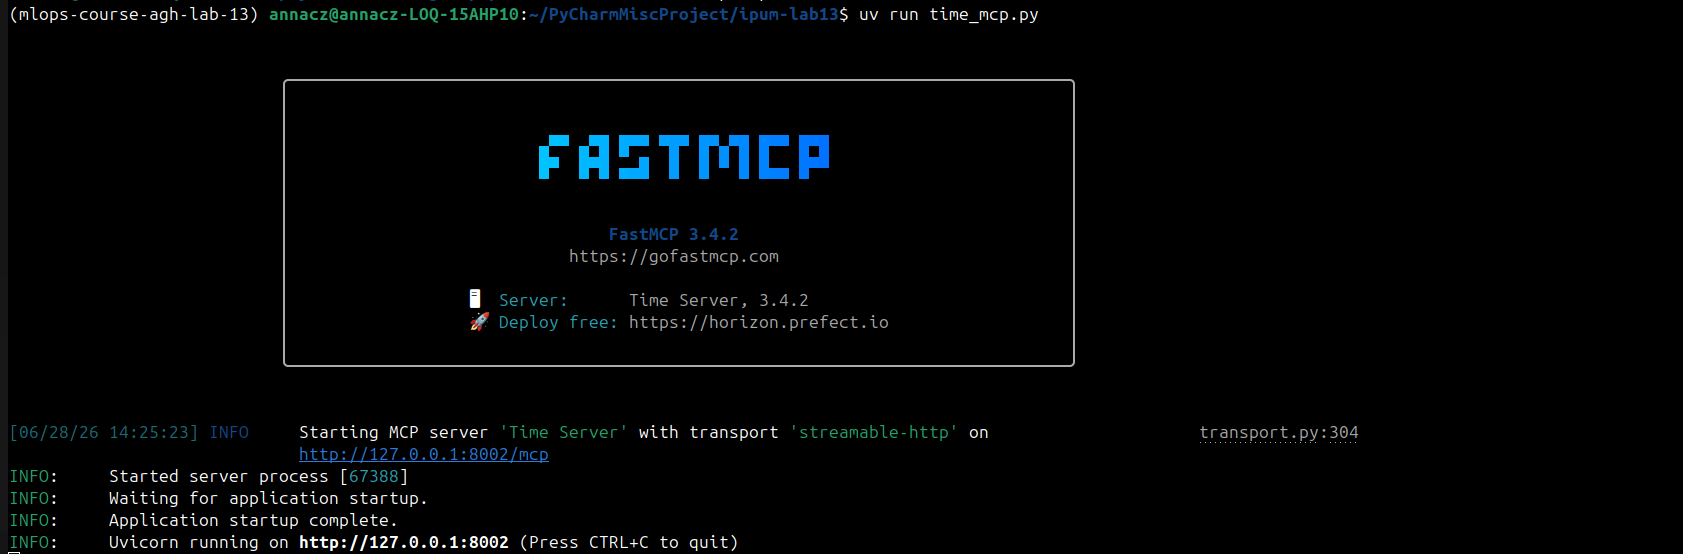

Files to exercise 3:
- ```weather_mcp.py``` -> MPC server for weather
- ```time_mpc.py``` -> MPC server for date
- ```weather_client.py``` -> MPC client for weather (incl.testing prompts)

**Exercise 4:**

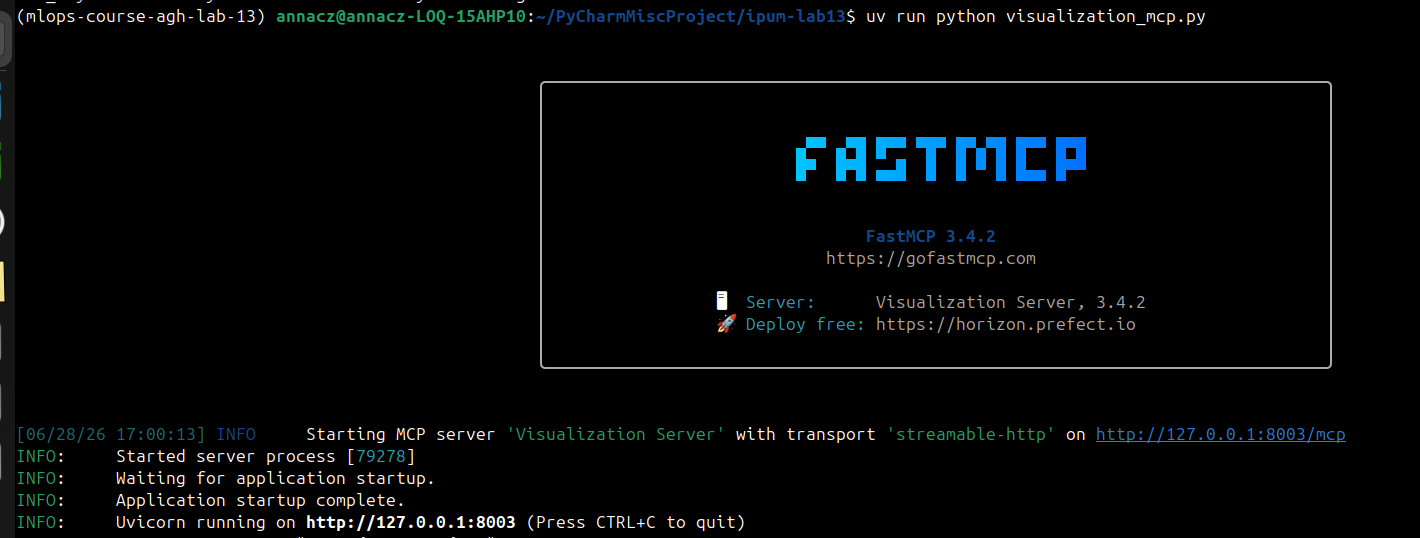

Files to exercise 4:
- ```visualization_mcp.py``` -> MPC server for visualization
- ```plot_client.py``` -> MPC client for creating a line plot
- ```plot.png``` -> decoded image by plot_client
